In [13]:
import os
import pandas as pd
import numpy as np
import pyBigWig as pw
beddir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/"
odir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/digital_footprinting/output/"
for cellline in ["HEPG2", "K562"]:
    chip_pp="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/digital_footprinting/"+cellline+".bigwig"
    bw_cp = pw.open(chip_pp)
    
    for dirname in os.listdir(os.path.join(beddir, cellline)):
        for filename in os.listdir(os.path.join(beddir+cellline, dirname)):
            bedfile = os.path.join(os.path.join(beddir+cellline, dirname),filename)
            print(bedfile)
            datadf=pd.read_csv(bedfile, sep="\t", header=None)
            
            dg_values = []
            for i,r in datadf.iterrows():
                mid=int((r[1]+r[2])/2)
                val1 = np.mean(np.log10(np.nan_to_num(bw_cp.values(r[0],mid-50,mid+50))+1e-50)*-1)
                #print(np.max(bw_cp.values(r[0],mid-50,mid+50)))
                #print(val1)
                dg_values.append(val1)
                #break
            datadf["dgf"] = dg_values 
            #print(os.path.join(odir+cellline, dirname))
            if not os.path.exists(os.path.join(odir+cellline, dirname)):
                os.makedirs(os.path.join(odir+cellline, dirname))
            datadf.to_csv(os.path.join(os.path.join(odir+cellline, dirname),filename), sep="\t", index=False, header=False)
        #break

/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_15_FOXA1/ENCSR000BLE.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_15_FOXA1/ENCSR000BMO.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_15_FOXA1/ENCSR267DFA.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_15_FOXA1/ENCSR865RXA.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_12_FOXA1/ENCSR000BLE.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEPG2/pattern_12_FOXA1/ENCSR000BMO.bed
/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/figure_5/chip_seq_compare/new_output_oct_25/HEP

In [14]:
import pandas as pd
from scipy import stats
import os
import numpy as np

names = ["chr", "start", "end", "name", "pwm", "strand", "pchr", "pstart", "pend", "tobias", "atac_counts", "atac_profile", "dnase_counts", "dnase_profile", "chip", "atac_obs", "dnase_obs", "dgf"]

celltypes = ["GM12878", "K562", "HEPG2", "H1ESC"]
main_dir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/digital_footprinting/output/"
method=[]
celltype=[]
pearsonrs=[]
for cl in celltypes:
    pairs = os.listdir(main_dir+cl)
    for pair in pairs:
        beds = os.listdir(main_dir+cl+"/"+pair)
        pair_pp = []
        #print(pair)
        #print("\n")
        for bed in beds:
            data = pd.read_csv(main_dir+cl+"/"+pair+"/"+bed, sep='\t', names=names)
            if data.shape[0] > 200:            
                data["label"] = True
                
                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), np.log(data[data["label"]]["atac_obs"].abs()+1))[0])
                celltype.append(cl)
                method.append("ATAC Observed log counts")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), np.log(data[data["label"]]["dnase_obs"].abs()+1))[0])
                celltype.append(cl)
                method.append("DNase Observed log counts")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), np.log(data[data["label"]]["tobias"].abs()))[0])
                celltype.append(cl)
                method.append("TOBIAS score")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), data[data["label"]]["atac_counts"].abs())[0])
#               #  print(pearsonrs[-1])
#               #  print(cl , bed)
                celltype.append(cl)
                method.append("ChromBPNet ATAC counts contrib")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), data[data["label"]]["atac_profile"].abs())[0])
                celltype.append(cl)
                method.append("ChromBPNet ATAC profile contrib")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), data[data["label"]]["dnase_counts"].abs())[0])
#                 print(pearsonrs[-1])
#                 print(cl , bed)
                celltype.append(cl)
                method.append("ChromBPNet DNase counts contrib")

                pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), data[data["label"]]["dnase_profile"].abs())[0])
                celltype.append(cl)
                method.append("ChromBPNet DNase profile contrib")
                
                if cl in ["HEPG2", "K562"]:
                    pearsonrs.append(stats.pearsonr(data[data["label"]]["chip"].abs(), data[data["label"]]["dgf"].abs())[0])
                    celltype.append(cl)
                    method.append("DGF")
                    #print(pearsonrs[-1], cl, bed)

In [15]:
dicts = {"method":method, "celltype":celltype, "pearsonrs":pearsonrs}
df = pd.DataFrame(dicts) 


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42 

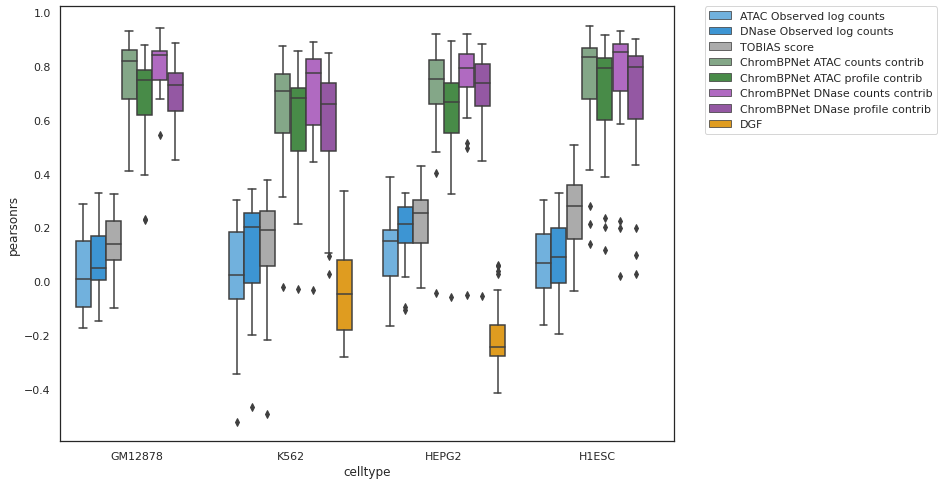

In [20]:
sns.set(rc={'figure.figsize':(11,8)})
sns.set_theme(style='white')
my_pal = {"ATAC Observed log counts": "#5FB4EF", "DNase Observed log counts": "#249AEC", "TOBIAS score": "#ABABAB",
         "ChromBPNet ATAC counts contrib": "#7EAD84", "ChromBPNet ATAC profile contrib":"#3D963D",
         "ChromBPNet DNase counts contrib": "#B95BD0", "ChromBPNet DNase profile contrib":"#9B4CAF", "DGF":"#FFA500"}

sns.boxplot(data=df, x="celltype", y="pearsonrs", hue="method", palette=my_pal)


plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.savefig("figures/dgf_added.pdf", transparent=True, dpi=300)


In [21]:
cl="HEPG2"
pp="pattern_0_CTCF"
bed="ENCSR607XFI.bed"

main_dir="/mnt/lab_data2/anusri/chrombpnet/src/evaluation/figure_notebooks/reviews/digital_footprinting/output/"
data = pd.read_csv(main_dir+cl+"/"+pp+"/"+bed, sep='\t', names=names)
data["label"]=True
data = data[data["label"]]

data["atac_obs_log"] = np.log(data["atac_obs"]+1)
data["dnase_obs_log"] = np.log(data["dnase_obs"]+1)
import scipy.stats

def make_plot(keyd, data, color, savef, ax):
    sns.kdeplot(
        ax=ax,
        data=data,
        x="chip",
        y=keyd,
        levels=5,
        fill=False,
        alpha=0.2,
        color="grey",
        cut=2,

    )

    sns.scatterplot(ax=ax, data=data, x="chip", y=keyd, s=2, color = color, rasterized=True)
    
    sns.regplot(ax=ax, x="chip", y=keyd, data=data, scatter=False, ci=None)
    ppr = scipy.stats.pearsonr(data[keyd], data["chip"])
    print(ppr)
    print(scipy.stats.pearsonr(data[keyd], data["chip"]))
    ax.set_title("Pearsonr: " + str(np.round(ppr[0],2)) + " pval: "+str(ppr[1]))
    ax.spines[['right', 'top']].set_visible(False)

    #plt.savefig(savef, dpi=300, transparent=True)


(-0.16318143794093093, 8.992160512767212e-275)
(-0.16318143794093093, 8.992160512767212e-275)
(0.18510790858542017, 0.0)
(0.18510790858542017, 0.0)
(0.05797335194144225, 6.661070192424517e-36)
(0.05797335194144225, 6.661070192424517e-36)
(0.9143176008842996, 0.0)
(0.9143176008842996, 0.0)
(0.8952325943264108, 0.0)
(0.8952325943264108, 0.0)
(0.9078184468683815, 0.0)
(0.9078184468683815, 0.0)
(0.8828439794081115, 0.0)
(0.8828439794081115, 0.0)
(-0.3514056813243952, 0.0)
(-0.3514056813243952, 0.0)


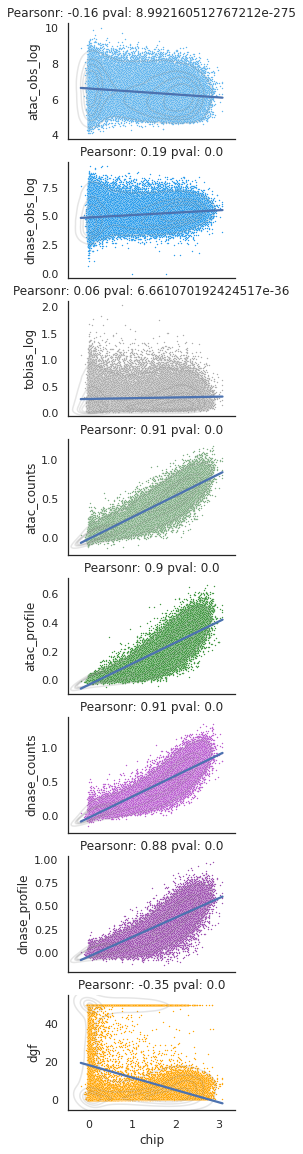

In [22]:

fig, axes = plt.subplots(8, 1, figsize=(3, 20), sharex=True)

make_plot("atac_obs_log", data, my_pal["ATAC Observed log counts"], "pearsonr_ctcf_obs.pdf", axes[0])
make_plot("dnase_obs_log", data, my_pal["DNase Observed log counts"], "pearsonr_ctcf_obs_dnase.pdf", axes[1])
data["tobias_log"] = np.log(data["tobias"]+1)
make_plot("tobias_log", data, my_pal["TOBIAS score"], "pearsonr_ctcf_tobias.pdf", axes[2])
make_plot("atac_counts", data, my_pal["ChromBPNet ATAC counts contrib"], "pearsonr_ctcf_counts.pdf", axes[3])
make_plot("atac_profile", data, my_pal["ChromBPNet ATAC profile contrib"], "pearsonr_ctcf_profile.pdf", axes[4])
make_plot("dnase_counts", data, my_pal["ChromBPNet DNase counts contrib"], "pearsonr_ctcf_counts_dnase.pdf", axes[5])
make_plot("dnase_profile", data, my_pal["ChromBPNet DNase profile contrib"], "pearsonr_ctcf_profile_dnase.pdf", axes[6])
make_plot("dgf", data, my_pal["DGF"], "pearsonr_ctcf_profile_dnase.pdf", axes[7])

plt.savefig("figures/ctcf_corrletation_plots.pdf", transparent=True, dpi=300)

#plt.savefig("all_plots.pdf", dpi=300, transparent=True)